In [12]:
from disk_analyzer.research.paths import artifacts_dir
import os
import pickle
EXP_NUM = 138
RES_FOLDER = str(artifacts_dir(EXP_NUM))
MODELS_FOLDER = os.path.join(RES_FOLDER, "models")
with open(os.path.join(MODELS_FOLDER, '0_CoxTILN.pkl'), 'rb') as f:
    model = pickle.load(f)

In [13]:
model.print_summary()

/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/lifelines/utils/printer.py:62: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  return summary_df[columns].to_latex(float_format="%." + str(self.decimals) + "f")


<lifelines.CoxTimeInvariantLNFitter: fitted with 339868 total observations, 295117 right-censored observations>
             duration col = 'duration'
                event col = 'failure'
                penalizer = 0.1
                 l1 ratio = 0
      baseline estimation = breslow
   number of observations = 339868
number of events observed = 44751
   partial log-likelihood = -1053121.95
         time fit was run = 2026-04-10 13:39:11 UTC

---
                 coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                              
smart_198_raw   -0.57       0.57       0.01            -0.58            -0.56                 0.56                 0.57
smart_191_raw   -4.11       0.02       0.01            -4.12            -4.10                 0.02                 0.02
smart_242_raw   -0.91       0.40       0.01            -0.92            -0.90                 0.40                 0.41
smart_189_raw   -0.03       0.97       0.01            -0.05            -0.02                 0.96                 0.98
smart_199_raw   -0.01       0.99       0.01            -0.02             0.00                 0.98                 1.00
smart_190_raw    0.61       1.83       0.00             0.60             0.61                 1.82                 1.85
smart_241_raw    0.32       1.38       0.00             0.31             0.33                 1.37                 1.39
smart_192_raw   -0.07       0.93       0.01            -0.08            -0.06                 0.92                 0.94
smart_12_raw    -0.00       1.00       0.01            -0.01             0.01                 0.99                 1.01
smart_5_raw     -0.47       0.63       0.01            -0.48            -0.46                 0.62                 0.63
smart_8_raw     -0.15       0.86       0.01            -0.16            -0.14                 0.85                 0.87
smart_240_raw    0.04       1.04       0.00             0.04             0.05                 1.04                 1.05
smart_10_raw     0.00       1.00       0.01            -0.01             0.02                 0.99                 1.02
smart_197_raw   -0.56       0.57       0.01            -0.57            -0.55                 0.56                 0.58
capacity_bytes   0.59       1.80       0.00             0.58             0.60                 1.79                 1.82
smart_193_raw   -0.12       0.89       0.01            -0.13            -0.11                 0.88                 0.90
smart_1_raw      0.23       1.26       0.00             0.22             0.24                 1.25                 1.27
smart_184_raw    0.02       1.02       0.00             0.02             0.03                 1.02                 1.03
smart_3_raw     -0.16       0.85       0.00            -0.17            -0.15                 0.85                 0.86
smart_4_raw     -0.86       0.43       0.01            -0.87            -0.84                 0.42                 0.43
smart_194_raw   -1.59       0.20       0.00            -1.60            -1.58                 0.20                 0.21
smart_2_raw     -0.16       0.85       0.01            -0.17            -0.15                 0.85                 0.86
smart_196_raw   -2.18       0.11       0.01            -2.19            -2.17                 0.11                 0.11
smart_183_raw   -0.00       1.00       0.00            -0.01             0.00                 0.99                 1.00
smart_9_raw     -0.12       0.89       0.00            -0.13            -0.11                 0.88                 0.90
smart_7_raw      0.00       1.00       0.00            -0.00             0.01                 1.00                 1.01
smart_188_raw    0.01       1.01       0.00             0.01             0.01                 1.01                 1.01
smart_187_raw   -0.00       1.00       0.01            -0.01       

In [14]:
import pandas as pd

df_tr = pd.read_parquet("fit_on.parquet")
# df_tr = pd.read_parquet("Data/Preprocessed_new_data/20_train_preprocessed.parquet")
df_tr_old = pd.read_parquet("Data/Preprocessed_old_alike/20_train_preprocessed.parquet")

In [2]:
df_diff = ((df_tr.describe() - df_tr_old.describe() + 1e-7) / (df_tr.describe() + 1e-7)).abs()
ft = df_diff.columns[df_diff.max(axis=0) > 100]
# df_diff[ft]
# df_tr.describe()[ft].round(4)
# df_tst.describe()[ft]

In [3]:
df_tr_old

,smart_198_raw,smart_191_raw,max_lifetime,smart_242_raw,time,smart_189_raw,serial_number,smart_199_raw,smart_190_raw,smart_241_raw,...,smart_4_raw,smart_194_raw,smart_2_raw,smart_196_raw,smart_183_raw,smart_9_raw,smart_7_raw,smart_188_raw,smart_187_raw,failure
0,-0.006937,-0.024811,6,-0.044121,0,-0.011299,0F112CC45,-0.030496,2.039531,3.531673,...,-0.040967,0.532896,-0.834014,-0.042292,0.007052,-1.007048,-0.011054,-0.003374,-0.004033,False
1,-0.006937,-0.024811,6,-0.043261,1,-0.011299,0F112CC45,-0.030496,2.125491,3.536529,...,-0.040967,0.739042,-0.834014,-0.042292,0.007052,-1.005432,-0.011054,-0.003374,-0.004033,False
2,-0.006937,-0.024811,6,-0.042570,2,-0.011299,0F112CC45,-0.030496,2.125491,3.541900,...,-0.040967,0.739042,-0.834014,-0.042292,0.007052,-1.003817,-0.011053,-0.003374,-0.004033,False
3,-0.006937,-0.024811,6,-0.041655,3,-0.011299,0F112CC45,-0.030496,2.125491,3.543813,...,-0.040967,0.739042,-0.834014,-0.042292,0.007052,-1.002202,-0.011052,-0.003374,-0.004033,False
4,-0.006937,-0.024811,6,-0.040789,4,-0.011299,0F112CC45,-0.030496,1.953572,3.546347,...,-0.040967,0.326749,-0.834014,-0.042292,0.007052,-1.000586,-0.011052,-0.003374,-0.004033,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357046,-0.006937,-0.024811,16,-0.102504,12,-0.011299,ZCH086CR,-0.033582,1.695694,-0.004477,...,-0.040967,-0.291691,-0.834014,-0.042292,-0.010780,-1.941243,-0.011312,-0.003374,-0.004033,True
357047,-0.006937,-0.024811,16,-0.100798,13,-0.011299,ZCH086CR,-0.033582,1.695694,0.032247,...,-0.040967,-0.291691,-0.834014,-0.042292,-0.010780,-1.939628,-0.011310,-0.003374,-0.004033,True
357048,-0.006937,-0.024811,16,-0.098988,14,-0.011299,ZCH086CR,-0.033582,1.695694,0.068806,...,-0.040967,-0.291691,-0.834014,-0.042292,-0.010780,-1.938012,-0.011309,-0.003374,-0.004033,True
357049,-0.006937,-0.024811,16,-0.097306,15,-0.011299,ZCH086CR,-0.033582,1.695694,0.101386,...,-0.040967,-0.291691,-0.834014,-0.042292,-0.010780,-1.936397,-0.011307,-0.003374,-0.004033,True


In [4]:
df_tr

,smart_198_raw,smart_191_raw,smart_242_raw,smart_189_raw,smart_199_raw,smart_190_raw,smart_241_raw,smart_192_raw,smart_12_raw,smart_5_raw,...,smart_194_raw,smart_2_raw,smart_196_raw,smart_183_raw,smart_9_raw,smart_7_raw,smart_188_raw,smart_187_raw,failure,duration
0,-0.006937,-0.024811,-0.044121,-0.011299,-0.030496,2.039531,3.531673,-0.677588,-0.508903,-0.021975,...,0.532896,-0.834014,-0.042292,0.007052,-1.007048,-0.011054,-0.003374,-0.004033,0,6
1,-0.006937,-0.024811,-0.043261,-0.011299,-0.030496,2.125491,3.536529,-0.677588,-0.508903,-0.021975,...,0.739042,-0.834014,-0.042292,0.007052,-1.005432,-0.011054,-0.003374,-0.004033,0,5
2,-0.006937,-0.024811,-0.042570,-0.011299,-0.030496,2.125491,3.541900,-0.677588,-0.508903,-0.021975,...,0.739042,-0.834014,-0.042292,0.007052,-1.003817,-0.011053,-0.003374,-0.004033,0,4
3,-0.006937,-0.024811,-0.041655,-0.011299,-0.030496,2.125491,3.543813,-0.677588,-0.508903,-0.021975,...,0.739042,-0.834014,-0.042292,0.007052,-1.002202,-0.011052,-0.003374,-0.004033,0,3
4,-0.006937,-0.024811,-0.040789,-0.011299,-0.030496,1.953572,3.546347,-0.677588,-0.508903,-0.021975,...,0.326749,-0.834014,-0.042292,0.007052,-1.000586,-0.011052,-0.003374,-0.004033,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339863,-0.006937,-0.024811,-0.104260,-0.011299,-0.033582,1.695694,-0.040984,-0.677588,-0.538763,-0.021975,...,-0.291691,-0.834014,-0.042292,-0.010780,-1.942858,-0.011314,-0.003374,-0.004033,1,5
339864,-0.006937,-0.024811,-0.102504,-0.011299,-0.033582,1.695694,-0.004477,-0.677588,-0.508903,-0.021975,...,-0.291691,-0.834014,-0.042292,-0.010780,-1.941243,-0.011312,-0.003374,-0.004033,1,4
339865,-0.006937,-0.024811,-0.100798,-0.011299,-0.033582,1.695694,0.032247,-0.677588,-0.508903,-0.021975,...,-0.291691,-0.834014,-0.042292,-0.010780,-1.939628,-0.011310,-0.003374,-0.004033,1,3
339866,-0.006937,-0.024811,-0.098988,-0.011299,-0.033582,1.695694,0.068806,-0.677588,-0.508903,-0.021975,...,-0.291691,-0.834014,-0.042292,-0.010780,-1.938012,-0.011309,-0.003374,-0.004033,1,2


KeyError: 'max_lifetime'

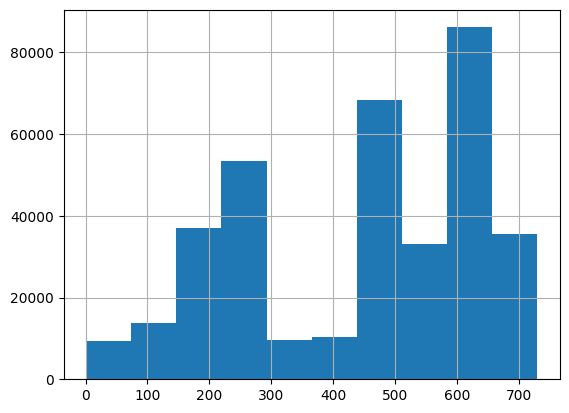

In [5]:
df_tr_old["max_lifetime"].hist()
df_tr["max_lifetime"].hist()

In [ ]:
# df_tr['duration'] = df_tr['max_lifetime'] - df_tr['time']
# df_tr_clear = df_tr.drop(columns=["serial_number", "max_lifetime", "time"])
# df_tr_clear =

In [15]:
from lifelines import CoxPHFitter

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_tr_clear, duration_col="duration", event_col="failure")
cph.print_summary()

/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/lifelines/utils/__init__.py:997: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  nonnumeric_cols = [col for (col, dtype) in df.dtypes.iteritems() if dtype.name == "category" or dtype.kind not in "biuf"]
/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/lifelines/utils/__init__.py:1123: ConvergenceWarning: Column smart_198_raw have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['failure'].astype(bool)
>>> print(df.loc[events, 'smart_198_raw'].var())
>>> print(df.loc[~events, 'smart_198_raw'].var())

A very low variance means that the column smart_198_raw completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logisti

<lifelines.CoxPHFitter: fitted with 339868 total observations, 295117 right-censored observations>
             duration col = 'duration'
                event col = 'failure'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 339868
number of events observed = 44751
   partial log-likelihood = -1053121.95
         time fit was run = 2026-04-10 13:50:18 UTC

---
                 coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                              
smart_198_raw   -0.57       0.57       0.01            -0.58            -0.56                 0.56                 0.57
smart_191_raw   -4.11       0.02       0.01            -4.12            -4.10                 0.02                 0.02
smart_242_raw   -0.91       0.40       0.01            -0.92            -0.90                 0.40                 0.41
smart_189_raw   -0.03       0.97       0.01            -0.05            -0.02                 0.96                 0.98
smart_199_raw   -0.01       0.99       0.01            -0.02             0.00                 0.98                 1.00
smart_190_raw    0.61       1.83       0.00             0.60             0.61                 1.82                 1.85
smart_241_raw    0.32       1.38       0.00             0.31             0.33                 1.37                 1.39
smart_192_raw   -0.07       0.93       0.01            -0.08            -0.06                 0.92                 0.94
smart_12_raw    -0.00       1.00       0.01            -0.01             0.01                 0.99                 1.01
smart_5_raw     -0.47       0.63       0.01            -0.48            -0.46                 0.62                 0.63
smart_8_raw     -0.15       0.86       0.01            -0.16            -0.14                 0.85                 0.87
smart_240_raw    0.04       1.04       0.00             0.04             0.05                 1.04                 1.05
smart_10_raw     0.00       1.00       0.01            -0.01             0.02                 0.99                 1.02
smart_197_raw   -0.56       0.57       0.01            -0.57            -0.55                 0.56                 0.58
capacity_bytes   0.59       1.80       0.00             0.58             0.60                 1.79                 1.82
smart_193_raw   -0.12       0.89       0.01            -0.13            -0.11                 0.88                 0.90
smart_1_raw      0.23       1.26       0.00             0.22             0.24                 1.25                 1.27
smart_184_raw    0.02       1.02       0.00             0.02             0.03                 1.02                 1.03
smart_3_raw     -0.16       0.85       0.00            -0.17            -0.15                 0.85                 0.86
smart_4_raw     -0.86       0.43       0.01            -0.87            -0.84                 0.42                 0.43
smart_194_raw   -1.59       0.20       0.00            -1.60            -1.58                 0.20                 0.21
smart_2_raw     -0.16       0.85       0.01            -0.17            -0.15                 0.85                 0.86
smart_196_raw   -2.18       0.11       0.01            -2.19            -2.17                 0.11                 0.11
smart_183_raw   -0.00       1.00       0.00            -0.01             0.00                 0.99                 1.00
smart_9_raw     -0.12       0.89       0.00            -0.13            -0.11                 0.88                 0.90
smart_7_raw      0.00       1.00       0.00            -0.00             0.01                 1.00                 1.01
smart_188_raw    0.01       1.01       0.00             0.01             0.01                 1.01                 1.01
smart_187_raw   -0.00       1.00       0.01            -0.01             0.01 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import survivors.constants as cnt

times = cnt.get_bins(time=df_tr_clear["time"].values, cens=df_tr_clear["failure"].values)

cph.predict_survival_function(df_tr_clear[:20], times=times).plot(legend=False)

KeyError: 'time'

In [ ]:
from survivors.metrics import concordance_index, ibs_remain

y_tr = cnt.get_y(cens=df_tr["failure"].values, time=df_tr["time"].values)
sf_tr = cph.predict_survival_function(df_tr, times=times)

In [ ]:
sf_tr.values.T

array([[0.97027254, 0.9649987 , 0.95967607, ..., 0.05456904, 0.05330137,
        0.05265621],
       [0.97628709, 0.97206483, 0.96779873, ..., 0.09898863, 0.09715555,
        0.09621922],
       [0.96909865, 0.96362049, 0.95809287, ..., 0.0485601 , 0.04738732,
        0.04679087],
       ...,
       [0.95433416, 0.94631198, 0.93823997, ..., 0.01105934, 0.01066396,
        0.0104647 ],
       [0.94141705, 0.93120877, 0.92096249, ..., 0.0029742 , 0.00283759,
        0.0027693 ],
       [0.9444482 , 0.93474957, 0.92500916, ..., 0.00405426, 0.00387774,
        0.00378933]])

In [ ]:
ibs_remain(y_tr, y_tr, sf_tr.values.T, times=times)

0.1192486423747097

In [ ]:
df_tr["failure"].value_counts()

failure
False    309986
True      47065
Name: count, dtype: int64